In [21]:
from google.colab import files # implement the excel file in this colab file
uploaded=files.upload()

Saving heart_cleveland_upload.csv to heart_cleveland_upload (1).csv


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
data=pd.read_csv("heart_cleveland_upload.csv")

In [24]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


In [25]:
data.head(40)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


**Data Cleaning**

In [26]:
#let's check if we have any column h=that has all the same value in it
data.isnull().sum()
# no missing values


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [27]:
data.nunique() # this shows me the number of different values for each column (normal outcomes)

,0
age,41
sex,2
cp,4
trestbps,50
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [28]:
data.duplicated().sum() # so no duplicate rows

np.int64(0)

In [29]:
# now we want to check the datatype of each column
data.info()
#also good

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [30]:
#now let's check values range
data.describe()
# The statistical summary shows that the dataset contains 297 records with no missing values.
#The features have realistic distributions overall, but some variables such as trestbps, chol, and oldpeak show relatively wide ranges and extreme values.
#For example, trestbps ranges from 94 to 200, chol from 126 to 564, and oldpeak from 0 to 6.2, which may indicate the presence of high-risk patients rather than data errors.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [34]:
multi_class_cols = ['cp', 'thal', 'slope']
data = pd.get_dummies(data, columns=multi_class_cols, drop_first=True)

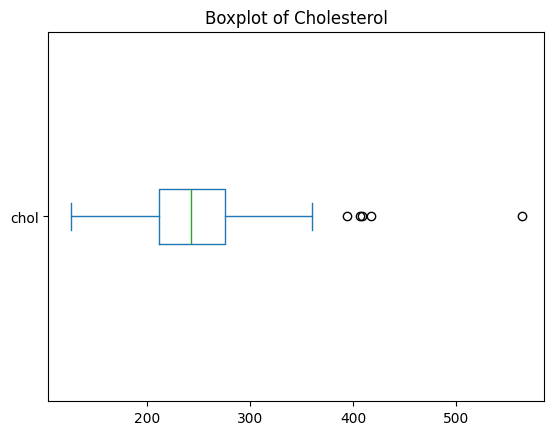

In [35]:
#now we will create a boxplot for each of these 3 columns where noticed that we have extreamly high values
data['chol'].plot.box(vert=False)
plt.title('Boxplot of Cholesterol')
plt.show()

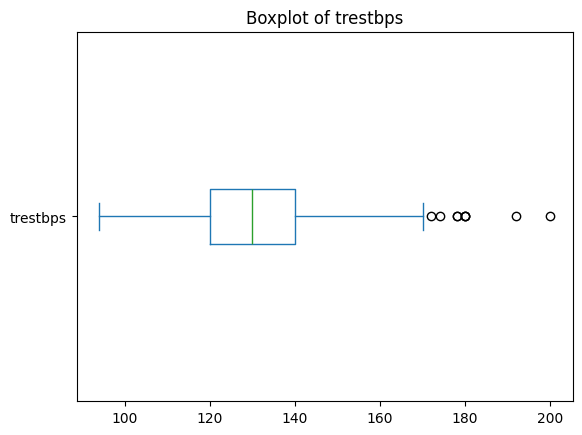

In [36]:
data['trestbps'].plot.box(vert=False)
plt.title('Boxplot of trestbps')
plt.show()

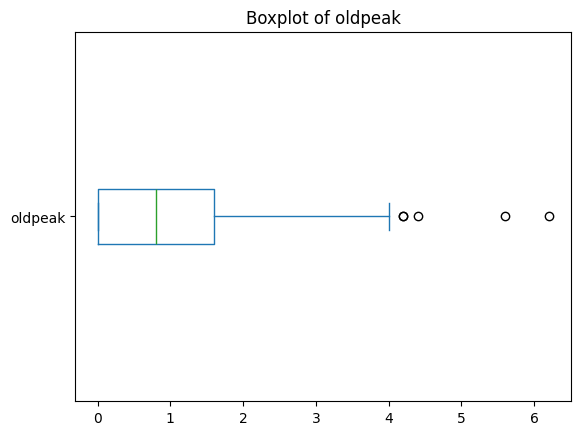

In [37]:
data['oldpeak'].plot.box(vert=False)
plt.title('Boxplot of oldpeak')
plt.show()

In [ ]:
# so we can notice form these 3 boxplot that we have outliers mainly on the upper (right) side of the distributions.
#These outliers indicate unusually high values compared to the rest of the data. However, since the dataset is medical in nature, these extreme values may represent high-risk patients rather than errors.
#Therefore, these outliers can provide valuable information for identifying risk patterns and should not be removed without careful justification.

In [ ]:
# as well we have several columns (0,1,2,3), but they are not qunatitaive , they are categorical , but encoded so either i covert them , or keep them depending on the model i wnana build

**Train-Test-Split**

In [38]:
X = data.drop('condition', axis=1) #like variables to predict something
y = data['condition'] #this is what i want to predict

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)
#75% of my data set is for training and 25% is for testing
len(X_train)

222

**Model Training**

In [39]:
from sklearn.tree import DecisionTreeClassifier # here i am telling him to import a decision tree #this is my main model evaluating all features
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)
# A Decision Tree Classifier was used as the machine learning model to predict heart disease.
# The model was trained using all available features (except the target variable 'condition').
# The model learns decision rules by splitting the data based on feature thresholds
# that best separate the two classes (0 = no disease, 1 = disease).

DecisionTreeClassifier()

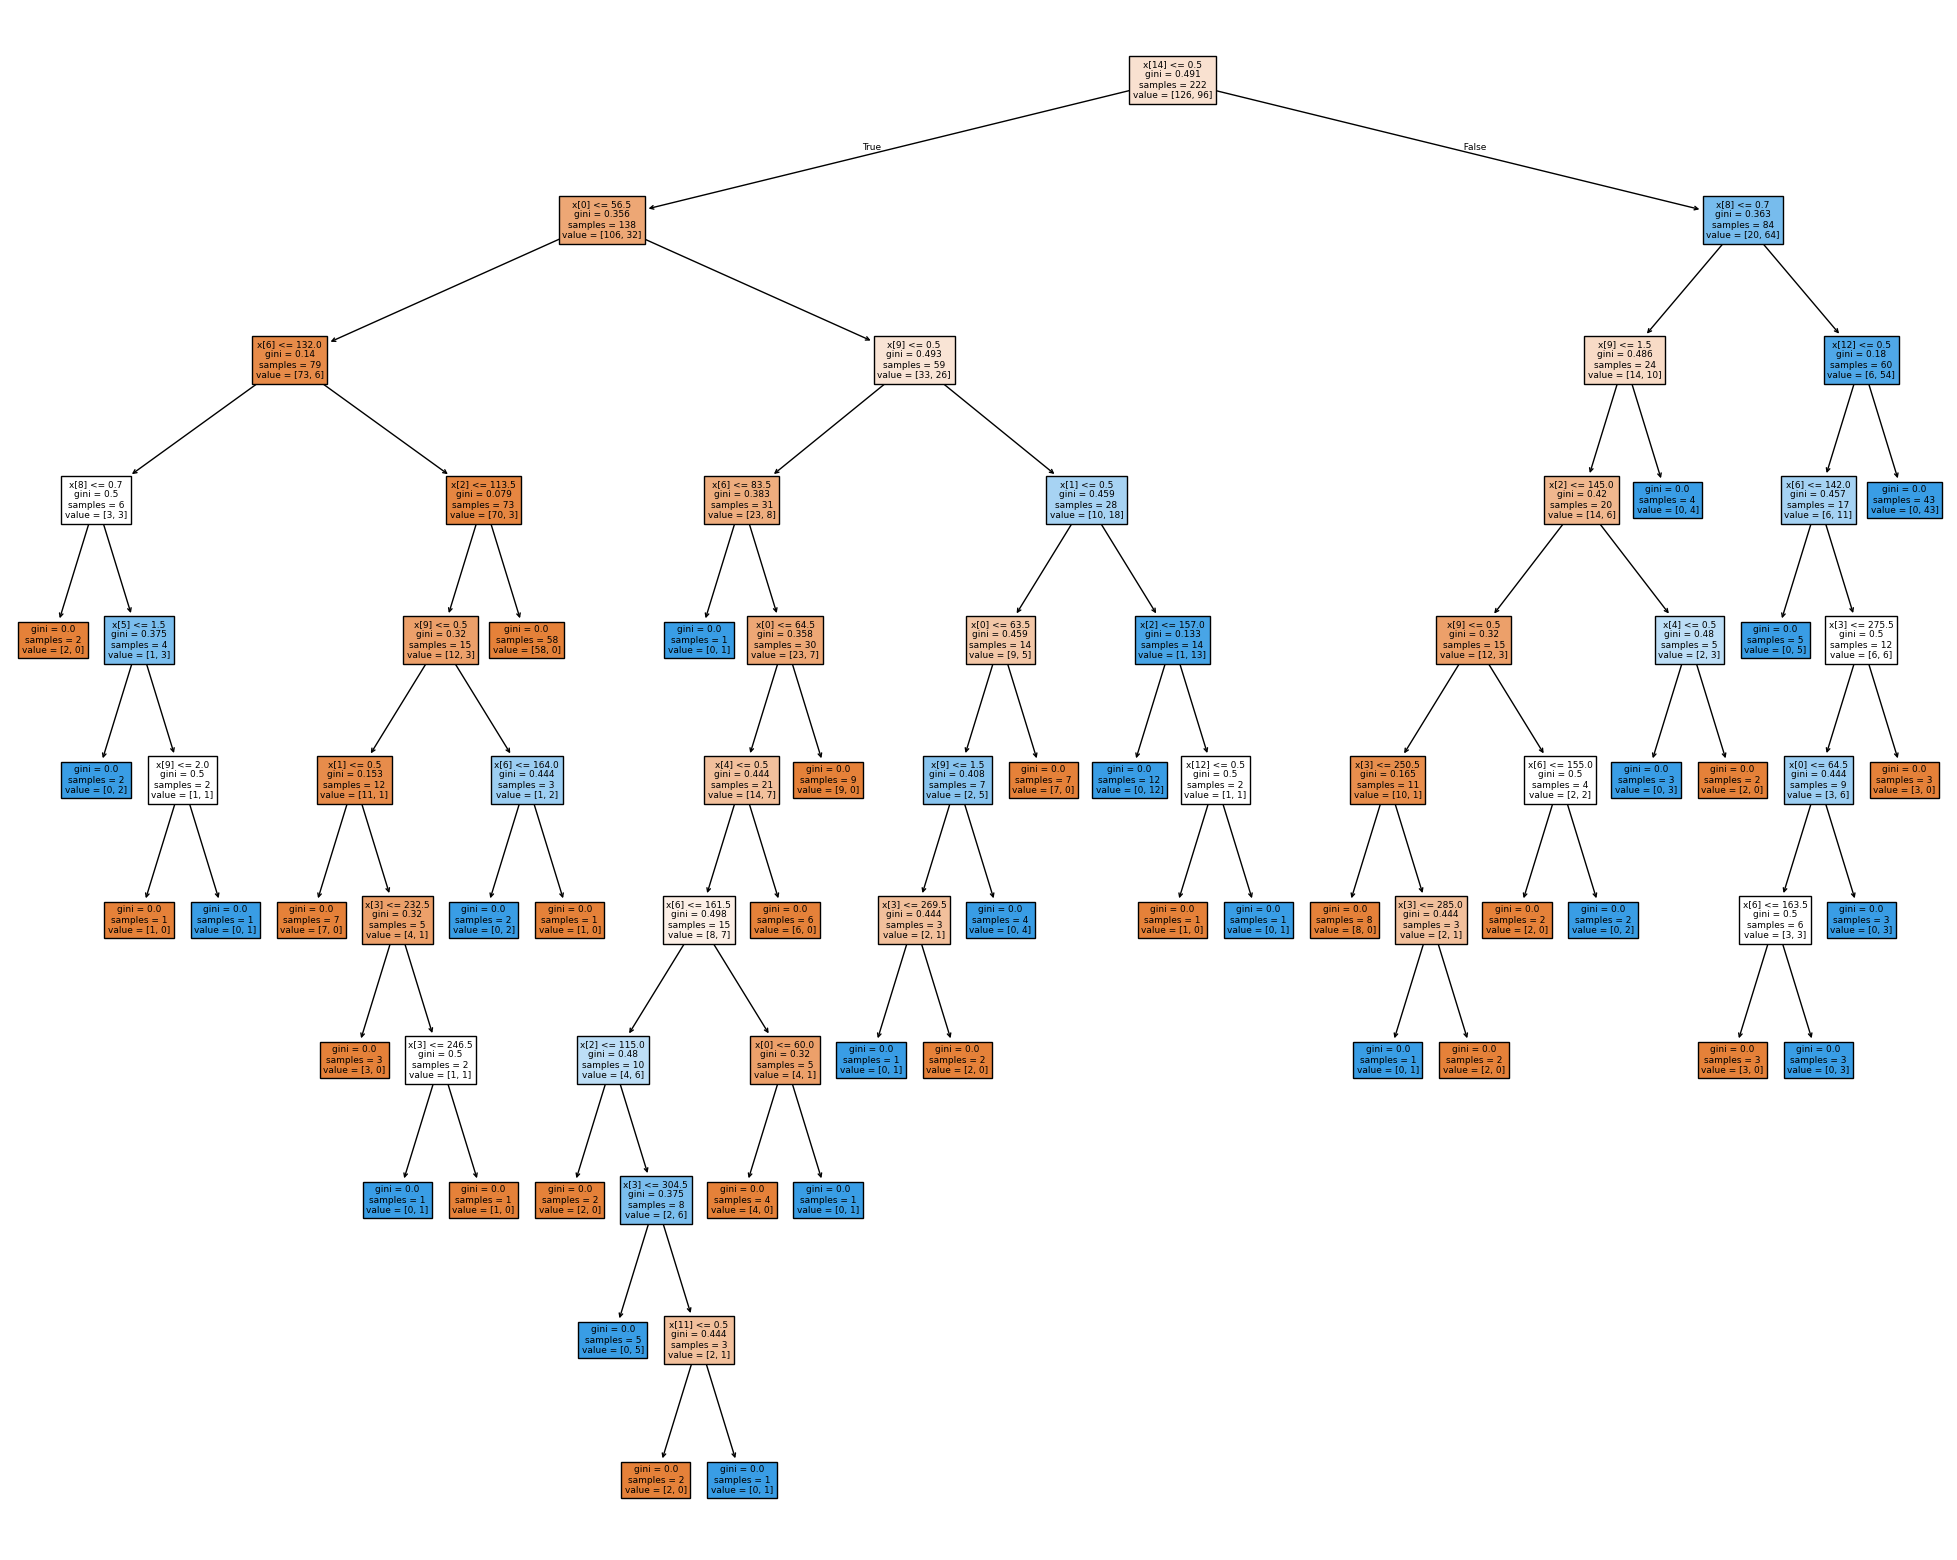

In [40]:
from sklearn import tree
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, filled=True) # it is a helper to know my model

**Model Evaluation**

In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Predict on the test set
y_pred = classifier.predict(X_test) # here i am using my classifier to predict the target
print(y_pred)
print()
print (y_test) # so i can compare the 2 arrays , y_pred and y_test
print()
print()
# Confusion Matrix # it gives me how many are false, correct for each class
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy # the percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



[1 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1
 1 0 0 1 1 0 1 1 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 1 1 0 0 1 0 1 1 1 0
 0]

111    0
150    0
12     1
216    1
139    0
      ..
27     0
218    0
256    0
37     0
92     0
Name: condition, Length: 75, dtype: int64


Confusion Matrix:
 [[21 13]
 [14 27]]
Accuracy: 0.64


**KNN Model**

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
from sklearn.neighbors import KNeighborsClassifier  # correct import

# Create the model
classifier = KNeighborsClassifier(n_neighbors=5)  # note: 'n_neighbors', not 'n_neighbours'

# Train the model
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [46]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Predict on the test set
y_pred = classifier.predict(X_test) # here i am using my classifier to predict the target
print(y_pred)
print()
print (y_test) # so i can compare the 2 arrays , y_pred and y_test
print()
print()
# Confusion Matrix # it gives me how many are false, correct for each class
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy # the percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1
 1 0 0 1 1 1 0 0 0 1 1 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 0
 0]

111    0
150    0
12     1
216    1
139    0
      ..
27     0
218    0
256    0
37     0
92     0
Name: condition, Length: 75, dtype: int64


Confusion Matrix:
 [[27  7]
 [ 8 33]]
Accuracy: 0.8


In [47]:
#KNN is better for prediction in this dataset
#The study shows that machine learning models can effectively predict heart disease using clinical features. KNN performed better than Decision Tree, achieving higher accuracy due to its ability to capture similarity between patients after feature scaling.

**Logistic Regression Model**

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LogisticRegression # here i am telling him to import a decision tree #this is my main model evaluating all features
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [52]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Predict on the test set
y_pred = classifier.predict(X_test) # here i am using my classifier to predict the target
print(y_pred)
print()
print (y_test) # so i can compare the 2 arrays , y_pred and y_test
print()
print()
# Confusion Matrix # it gives me how many are false, correct for each class
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy # the percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[0 0 0 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 1 1 1
 1 0 0 1 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0
 0]

111    0
150    0
12     1
216    1
139    0
      ..
27     0
218    0
256    0
37     0
92     0
Name: condition, Length: 75, dtype: int64


Confusion Matrix:
 [[30  4]
 [ 8 33]]
Accuracy: 0.84


In [ ]:
# Logistic Regression achieved the highest accuracy among all tested models (84%), indicating that it is the most suitable model for this dataset. It provides stable and reliable predictions and demonstrates strong performance in identifying heart disease cases.

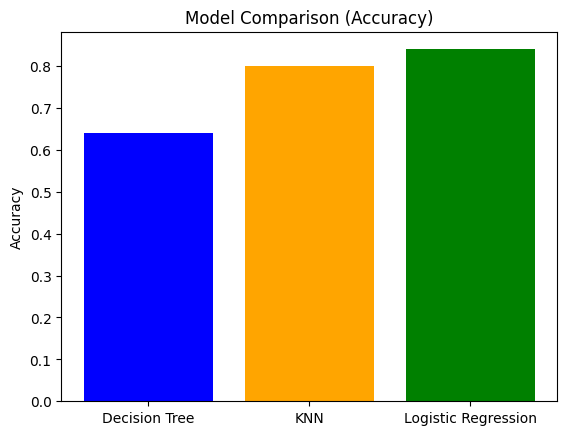

In [54]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'KNN', 'Logistic Regression']
accuracy = [0.64, 0.80, 0.84]

colors = ['blue', 'orange', 'green']

plt.bar(models, accuracy, color=colors)
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")

plt.show()